### Daily Salt Forecast

- Number of features: Quantity Consumed

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.utils.utils import load_file
from src.LSTM.model import get_device, ConsumptionDataset, LSTM, train_loop, test_loop

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

from copy import deepcopy as dc
from sklearn.preprocessing import MinMaxScaler

In [13]:
# Restaurant data with the 25 most frequent ingredients
restaurant_data_df = load_file('../../data/kaggle/Restaurant_frequent_ings.csv') 
#display(restaurant_data_df)

# Filter restaurant data by salt
restaurant_salt_data_df = restaurant_data_df[restaurant_data_df['Ingredient'] == 'salt'].copy()
display(restaurant_salt_data_df)

# Obtain daily salt consumption
restaurant_salt_data_df['DateTime'] = pd.to_datetime(restaurant_salt_data_df['DateTime']) # Convert DateTime column to datetime type
restaurant_salt_data_df['Date'] = restaurant_salt_data_df['DateTime'].dt.date # Extract date from DateTime
daily_salt_consumption = restaurant_salt_data_df.groupby(['Date'])['Total Quantity'].sum().reset_index() # group by Day
daily_salt_consumption = daily_salt_consumption.rename(columns={'Total Quantity': 'Quantity'}) # Rename 'Total Quantity' to 'Quantity'
display(daily_salt_consumption)

# Plot daily salt consumption 
plt.figure(figsize=(10, 6))
plt.plot(daily_salt_consumption['Date'], daily_salt_consumption['Quantity'], marker='o', linestyle='-')
plt.title('Daily salt Consumption')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

,OrderID,DateTime,Shift,DayType,DayOfWeek,PartySize,Category,MenuItem,ItemPrice,ItemQty,Factor,Ingredient,Quantity per Unit,Total Quantity
6,2,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,flatbread,11.00,1,1.082508,salt,2.737,2.962825
8,3,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Vegetable specials,sarson ka saag,15.00,1,1.082508,salt,1.730,1.872739
12,4,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Vegetable specials,curry vindaloo,16.00,1,1.082508,salt,1.730,1.872739
18,5,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Breads,garlic naan,3.50,2,1.082508,salt,0.910,0.985083
24,6,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Breads,naan,2.75,2,1.082508,salt,2.050,2.219142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83056,18095,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,onion kulcha,5.00,2,1.465347,salt,1.730,2.535050
83064,18097,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,tandoori roti,2.75,1,1.465347,salt,1.730,2.535050
83068,18098,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,naan,2.75,4,1.465347,salt,2.050,3.003960
83073,18099,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Vegetable specials,kadhai paneer,16.00,2,1.465347,salt,4.105,6.015248


ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [ ]:
daily_salt_consumption.head(20)

,Date,Quantity
0,2019-01-01,153.557043
1,2019-01-02,101.122931
2,2019-01-03,119.849399
3,2019-01-04,97.377637
4,2019-01-05,202.245861
5,2019-01-06,260.297914
6,2019-01-07,436.326719
7,2019-01-08,204.118508
8,2019-01-09,52.434112
9,2019-01-10,127.339987


In [4]:
def prepare_data_for_lstm(df, lookback, train_split=0.95, feature_range=(-1, 1)):
    # Deep copy the dataframe to avoid modifying the original data
    df = dc(df)   

    # Set the Date column as the index
    df.set_index('Date', inplace=True)  

    # Create shifted columns for the specified number of steps  
    for i in range(1, lookback+1):
        df[f'Qty(t-{i})'] = df['Quantity'].shift(i)

    # Drop rows with NaN values generated by the shift
    df.dropna(inplace=True)

    shifted_daily_consumption_df = df.copy()
    display(shifted_daily_consumption_df.head(10))

    # Convert the DataFrame to a numpy array
    shifted_df_as_np = shifted_daily_consumption_df.to_numpy() 
    #display(shifted_df_as_np)   # 2D array
    #print(f"After converting to numpy array - Shape: {shifted_df_as_np.shape}, Dimensions: {shifted_df_as_np.ndim}")

    # Scale the data
    scaler = MinMaxScaler(feature_range=feature_range)
    shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)
    # #display(shifted_df_as_np)
    # print(f"After scalling the data - Shape: {shifted_df_as_np.shape}, Dimensions: {shifted_df_as_np.ndim}", '\n')

    # Split into inputs (X) and target (y)
    X = shifted_df_as_np[:, 1:] # Input sequences   [t-1, t-2, t-3, t-4] (Day4, Day3, Day2, Day1)
    y = shifted_df_as_np[:, 0]  # Predicted values  [Day5 = t]  
    # print(f"X - Shape: {X.shape}, Dimensions: {X.ndim}")
    # print(f"y - Shape: {y.shape}, Dimensions: {y.ndim}", '\n')
    
    # Reverse the order of the input sequences
    X = dc(np.flip(X, axis=1))  #  [t-4, t-3, t-2, t-1] (Day1, Day2, Day3, Day4)

    # Determine the split index for training and testing data
    split_index = int(len(X) * train_split)
    print("Split_index: ", split_index)

    # Split the data into training and testing sets
    X_train = X[:split_index]
    X_test = X[split_index:]
    y_train = y[:split_index]
    y_test = y[split_index:]
    
    # Reshape the data for LSTM input
    ## Is a requirement for pytorch lstm to have an extra dimension at the end
    X_train = X_train.reshape((-1, lookback, 1))
    X_test = X_test.reshape((-1, lookback, 1))
    y_train = y_train.reshape((-1, 1))
    y_test = y_test.reshape((-1, 1))
    
    # Convert the numpy arrays to PyTorch tensors
    X_train = torch.tensor(X_train).float()
    y_train = torch.tensor(y_train).float()
    X_test = torch.tensor(X_test).float()
    y_test = torch.tensor(y_test).float()

    return X_train, y_train, X_test, y_test, scaler

In [5]:
# Get hardware for training 
device = get_device()

print("Daily Salt Consumption Dataset: ", "\n")
#display(daily_salt_consumption.tail(10))

print("Preparing dataset for lstm model ...")
lookback = 2    #  Size of window for prediction (shifts number)
X_train, y_train, X_test, y_test, scaler = prepare_data_for_lstm(daily_salt_consumption, lookback)

print(f"X train - Shape: {X_train.shape}, Dimensions: {X_train.ndim}")
print(f"X test - Shape: {X_test.shape}, Dimensions: {X_test.ndim}")
print(f"y train - Shape: {y_train.shape}, Dimensions: {y_train.ndim}")
print(f"y test - Shape: {y_test.shape}, Dimensions: {y_test.ndim}" '\n')

print("Creating Data Loader for batch training ...")
train_dataset = ConsumptionDataset(X_train, y_train)
test_dataset = ConsumptionDataset(X_test, y_test)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train Dataset:") 
print("Total number of samples: ", len(train_dataloader.dataset))
print("Total number of batches: ", len(train_dataloader), '\n')
print("Test Dataset:") 
print("Total number of samples: ", len(test_dataloader.dataset))
print("Total number of batches: ", len(test_dataloader), '\n')


# Iterate over the train_dataloader
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    print(batch)
    break

Using cuda device

Daily Salt Consumption Dataset:  

Preparing dataset for lstm model ...


,Quantity,Qty(t-1),Qty(t-2)
Date,,,
2019-01-03,119.849399,101.122931,153.557043
2019-01-04,97.377637,119.849399,101.122931
2019-01-05,202.245861,97.377637,119.849399
2019-01-06,260.297914,202.245861,97.377637
2019-01-07,436.326719,260.297914,202.245861
2019-01-08,204.118508,436.326719,260.297914
2019-01-09,52.434112,204.118508,436.326719
2019-01-10,127.339987,52.434112,204.118508
2019-01-11,35.580290,127.339987,52.434112


Split_index:  170
X train - Shape: torch.Size([170, 2, 1]), Dimensions: 3
X test - Shape: torch.Size([9, 2, 1]), Dimensions: 3
y train - Shape: torch.Size([170, 1]), Dimensions: 2
y test - Shape: torch.Size([9, 1]), Dimensions: 2

Creating Data Loader for batch training ...
Train Dataset:
Total number of samples:  170
Total number of batches:  6 

Test Dataset:
Total number of samples:  9
Total number of batches:  1 

torch.Size([32, 2, 1]) torch.Size([32, 1])
[tensor([[[-0.5509],
         [-0.7474]],

        [[-0.7474],
         [-0.6772]],

        [[-0.6772],
         [-0.7614]],

        [[-0.7614],
         [-0.3684]],

        [[-0.3684],
         [-0.1509]],

        [[-0.1509],
         [ 0.5088]],

        [[ 0.5088],
         [-0.3614]],

        [[-0.3614],
         [-0.9298]],

        [[-0.9298],
         [-0.6491]],

        [[-0.6491],
         [-0.9930]],

        [[-0.9930],
         [ 0.1930]],

        [[ 0.1930],
         [ 0.6070]],

        [[ 0.6070],
         [

In [6]:
features_number = 1 # 1 feature - quantity consumed
hidden_size = 32
num_stack_layers = 2
model = LSTM(features_number, hidden_size, num_stack_layers, device).to(device)
print("Creating LSTM model ...")
print(model)

learning_rate = 0.01
num_epochs = 10
loss_function = nn.MSELoss()    # loss function - Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

print("\n------------ LSTM Model Training & Evaluations Results ------------")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs} ")
    train_loop(train_dataloader, model, loss_function, optimizer, device)
    test_loop(test_dataloader, model, loss_function, device)
    print()
print("Done!")

Creating LSTM model ...
LSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

------------ LSTM Model Training & Evaluations Results ------------
Epoch 1/10 
Batch 0 - loss: 0.398529  [ 32/170]
Test Error: 
 Avg loss: 0.239537, MAE: 0.332124, MSE: 0.239537, RMSE: 0.489425 


Epoch 2/10 
Batch 0 - loss: 0.287230  [ 32/170]
Test Error: 
 Avg loss: 0.153948, MAE: 0.296920, MSE: 0.153948, RMSE: 0.392362 


Epoch 3/10 
Batch 0 - loss: 0.277047  [ 32/170]
Test Error: 
 Avg loss: 0.157714, MAE: 0.282573, MSE: 0.157714, RMSE: 0.397132 


Epoch 4/10 
Batch 0 - loss: 0.268779  [ 32/170]
Test Error: 
 Avg loss: 0.180268, MAE: 0.283307, MSE: 0.180268, RMSE: 0.424579 


Epoch 5/10 
Batch 0 - loss: 0.260919  [ 32/170]
Test Error: 
 Avg loss: 0.158415, MAE: 0.274330, MSE: 0.158415, RMSE: 0.398013 


Epoch 6/10 
Batch 0 - loss: 0.252568  [ 32/170]
Test Error: 
 Avg loss: 0.132582, MAE: 0.260970, MSE: 0.132582, RMSE: 0.364118 


Epoch 7

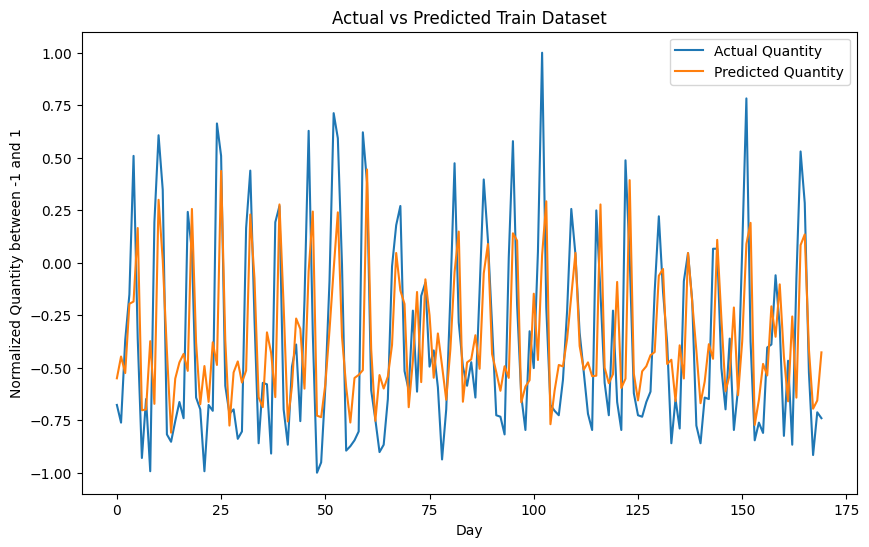

In [7]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()
    
plt.figure(figsize=(10, 6))
plt.plot(y_train, label='Actual Quantity')
plt.plot(predicted, label='Predicted Quantity')
plt.xlabel('Day')
plt.ylabel('Normalized Quantity between -1 and 1')
plt.legend()
plt.title("Actual vs Predicted Train Dataset")
plt.show()

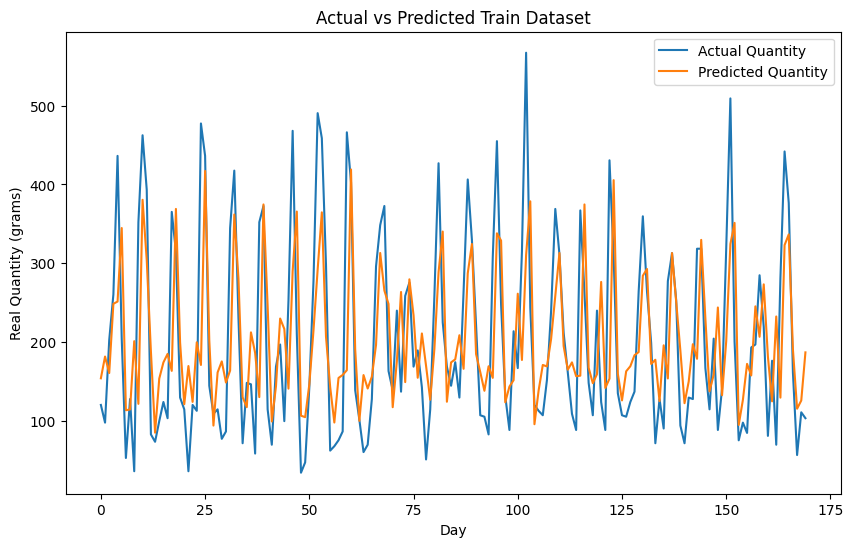

In [8]:
train_predictions = predicted.flatten()

dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = train_predictions
dummies = scaler.inverse_transform(dummies)

train_predictions = dc(dummies[:, 0])
train_predictions

dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = y_train.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_train = dc(dummies[:, 0])
new_y_train

plt.figure(figsize=(10, 6))
plt.plot(new_y_train, label='Actual Quantity')
plt.plot(train_predictions, label='Predicted Quantity')
plt.xlabel('Day')
plt.ylabel('Real Quantity (grams)')
plt.legend()
plt.title("Actual vs Predicted Train Dataset")
plt.show()

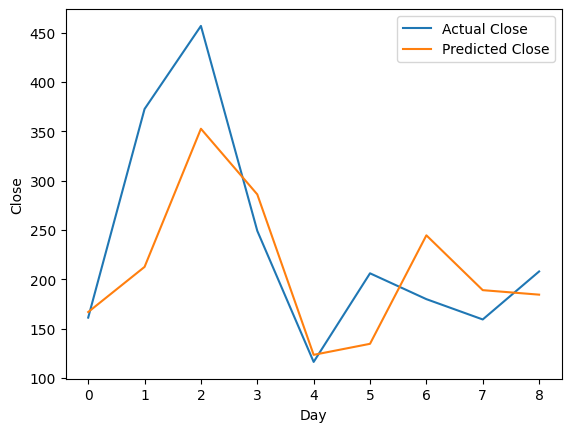

In [9]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = dc(dummies[:, 0])
#test_predictions

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = y_test.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_test = dc(dummies[:, 0])
#new_y_test

plt.plot(new_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()